# E-commerce Furniture Dataset 2024

**Objective: Predict the number of furniture items sold (sold) based on product attributes such as productTitle, originalPrice, price, and tagText.**

In [ ]:
import pandas as pd
import numpy as np

## 1. Load and Clean Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/E-commerce Furniture item solds/ecommerce_furniture_dataset_2024.csv')
df.sample(5)

,productTitle,originalPrice,price,sold,tagText
1692,Simple Shoe Rack Multi-Layer Space Saving Shoe...,$22.21,$7.33,13,Free shipping
1860,3 Pieces Patio Furniture Set Outdoor Conversat...,NaN,$86.35,1,Free shipping
1433,"4 Drawer Dresser, Drawer Chest, Tall Storage D...",NaN,$107.89,1,Free shipping
858,White Computer Desk with Drawers & Storage She...,NaN,$78.05,0,Free shipping
1563,Clouds Tea Table House Lonely Wind Nordic Home...,NaN,$293.95,15,Free shipping


In [ ]:
df.shape

(2000, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [ ]:
# convert originalPrice and price column to numeric and remove unwanted symbol
df['originalPrice'] = df['originalPrice'].str.replace(r'[$,]', '', regex=True).astype(float)
df['price'] = df['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df.sample(10)

,productTitle,originalPrice,price,sold,tagText
250,"4-Piece Rattan Patio Furniture Set, Chairs, an...",NaN,243.78,1,Free shipping
73,"Armoire Wardrobe Closet - White 32""W x 35""H x ...",NaN,159.73,0,Free shipping
1524,"GTRACING Gaming Chair, Computer Chair with Mes...",NaN,143.16,6,Free shipping
172,Patio Furniture Set 4-Piece Outdoor Rattan Wic...,NaN,339.10,0,Free shipping
84,Modern Small Bedside Table with Drawer Lock No...,98.79,49.39,1,Free shipping
36,3 Pieces Patio Furniture PE Rattan Wicker Chai...,NaN,86.80,18,Free shipping
1501,GIANXI Summer Outdoor Folding Chair Adult Sies...,61.32,28.38,36,Free shipping
1346,"Baysitone Clear Dining Chairs Set of 4, Modern...",NaN,159.46,3,Free shipping
302,Patio Furniture Sets - 3 Pieces Rattan Sofa Se...,NaN,183.30,0,Free shipping
944,"Faux Leather Dining Chairs, Button Tufted Dini...",NaN,80.76,0,Free shipping


In [ ]:
# check for missing values
df.isnull().sum()

,0
productTitle,0
originalPrice,1513
price,0
sold,0
tagText,3


Their is 1513 missing values in `originalPrice` column out of 2000 values.We have two solution of this problem:

1. We can drop this column because we have another column by the name of `Price`, which represents the current selling price.

2. We assume that for the null value there were no discounts and as such the price will also be the originalprice and copy the data.we will move forward with Option 2

In [ ]:
df['originalPrice'] = df['originalPrice'].fillna(df['price'])

In [ ]:
df.sample(5)

,productTitle,originalPrice,price,sold,tagText
1806,"Clothes Storage Wardrobe with Dustproof Cover,...",83.80,46.98,10,Free shipping
69,King Size Bed Frame Heavy Duty Bed Frame With ...,101.98,101.98,0,Free shipping
1285,Stackable Clear Acrylic Shoe Box Organizer Dou...,41.14,41.14,3,Free shipping
1468,Shoerack Shoes Organizer for Teeth Wallets and...,11.30,11.30,10,+Shipping: $5.09
1195,IHOME Lazy Sofa Tatami Home Living Room Dormit...,28.66,28.66,10,+Shipping: $69.95


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
productTitle,0
originalPrice,0
price,0
sold,0
tagText,0


Missing value problem solved ✅

In [ ]:
# Check for duplicate values
df.duplicated().sum()

np.int64(93)

In [ ]:
# remove duplicates
df = df.drop_duplicates()
df.head()

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",111.99,111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1,Free shipping


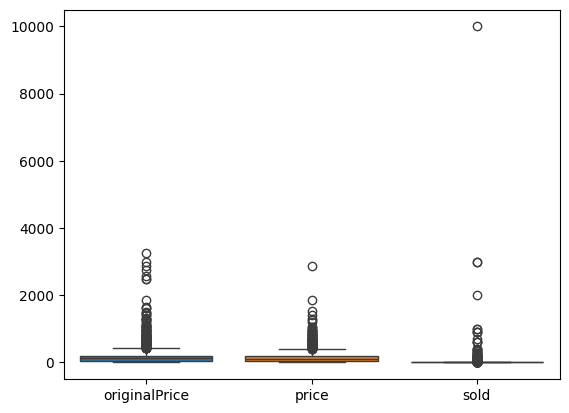

In [ ]:
# check for outliers
import seaborn as sns
sns.boxplot(df);

In [ ]:
# cap these outliers for price col
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

iqr = q3-q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
df['price'] = df['price'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
# cap these outliers for sold col
q1 = df['sold'].quantile(0.25)
q3 = df['sold'].quantile(0.75)

iqr = q3-q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
df['sold'] = df['sold'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
# cap these outliers for title length
q1 = df['originalPrice'].quantile(0.25)
q3 = df['originalPrice'].quantile(0.75)

iqr = q3-q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
df['originalPrice'] = df['originalPrice'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1904 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   productTitle   1904 non-null   object 
 1   originalPrice  1904 non-null   float64
 2   price          1904 non-null   float64
 3   sold           1904 non-null   float64
 4   tagText        1904 non-null   object 
dtypes: float64(3), object(2)
memory usage: 89.2+ KB


Convert tagtext column into numeric column: for Free shipping: 0 and for other the same shipping charges only remove the symbols and characters

In [ ]:
df['shipping'] = df['tagText'].apply(lambda x: 0 if x == 'Free shipping' else float(x.replace('+Shipping: $', '').replace(",","")))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1904 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   productTitle   1904 non-null   object 
 1   originalPrice  1904 non-null   float64
 2   price          1904 non-null   float64
 3   sold           1904 non-null   float64
 4   tagText        1904 non-null   object 
 5   shipping       1904 non-null   float64
dtypes: float64(4), object(2)
memory usage: 104.1+ KB


In [ ]:
# now remove the tagtext column
df = df.drop(['tagText'],axis=1)
df.head()

,productTitle,originalPrice,price,sold,shipping
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,46.79,21.625,0.0
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,169.72,0.000,0.0
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7.000,0.0
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",111.99,111.99,0.000,0.0
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1.000,0.0


Nice work 👍

## 2. Exploratory Data Analysis

### Univariate Analysis

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1904 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   productTitle   1904 non-null   object 
 1   originalPrice  1904 non-null   float64
 2   price          1904 non-null   float64
 3   sold           1904 non-null   float64
 4   shipping       1904 non-null   float64
dtypes: float64(4), object(1)
memory usage: 89.2+ KB


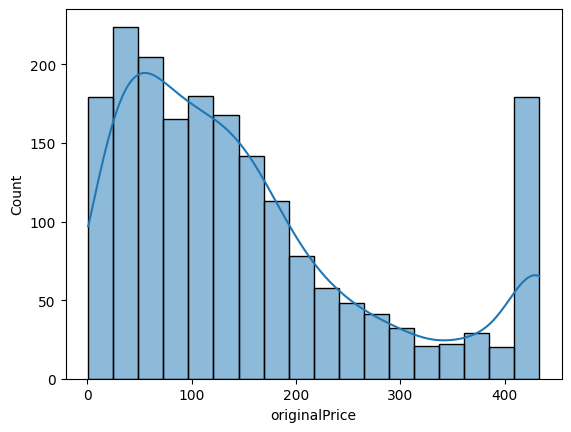

In [ ]:
# Original_price col
sns.histplot(df['originalPrice'],kde=True);

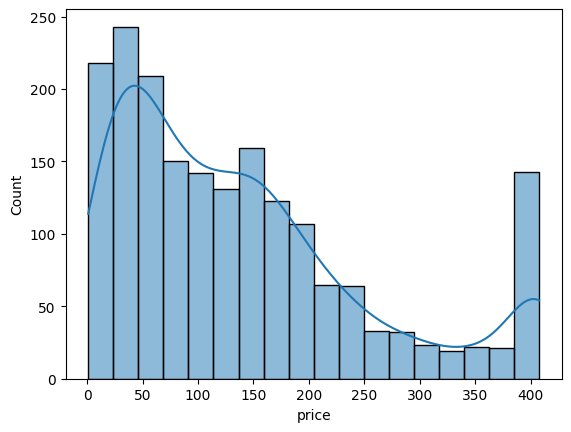

In [ ]:
# price col
sns.histplot(df['price'],kde=True);

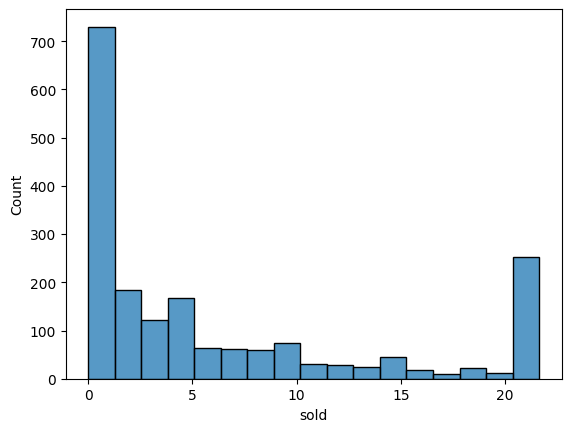

In [ ]:
# sold col
sns.histplot(df['sold']);

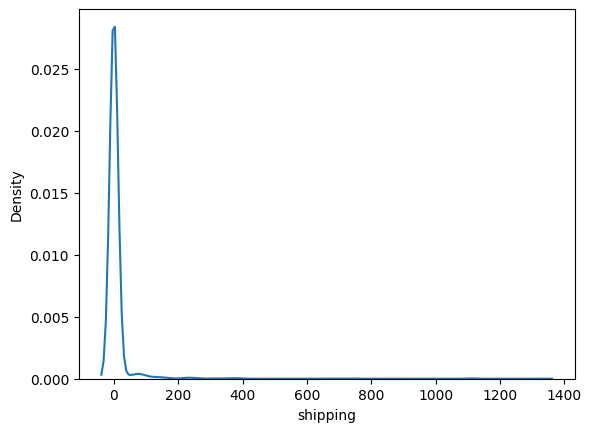

In [ ]:
# shipping col
sns.kdeplot(df['shipping']);

Right skwed columns.

###Bivariate and Multivariate Analysis

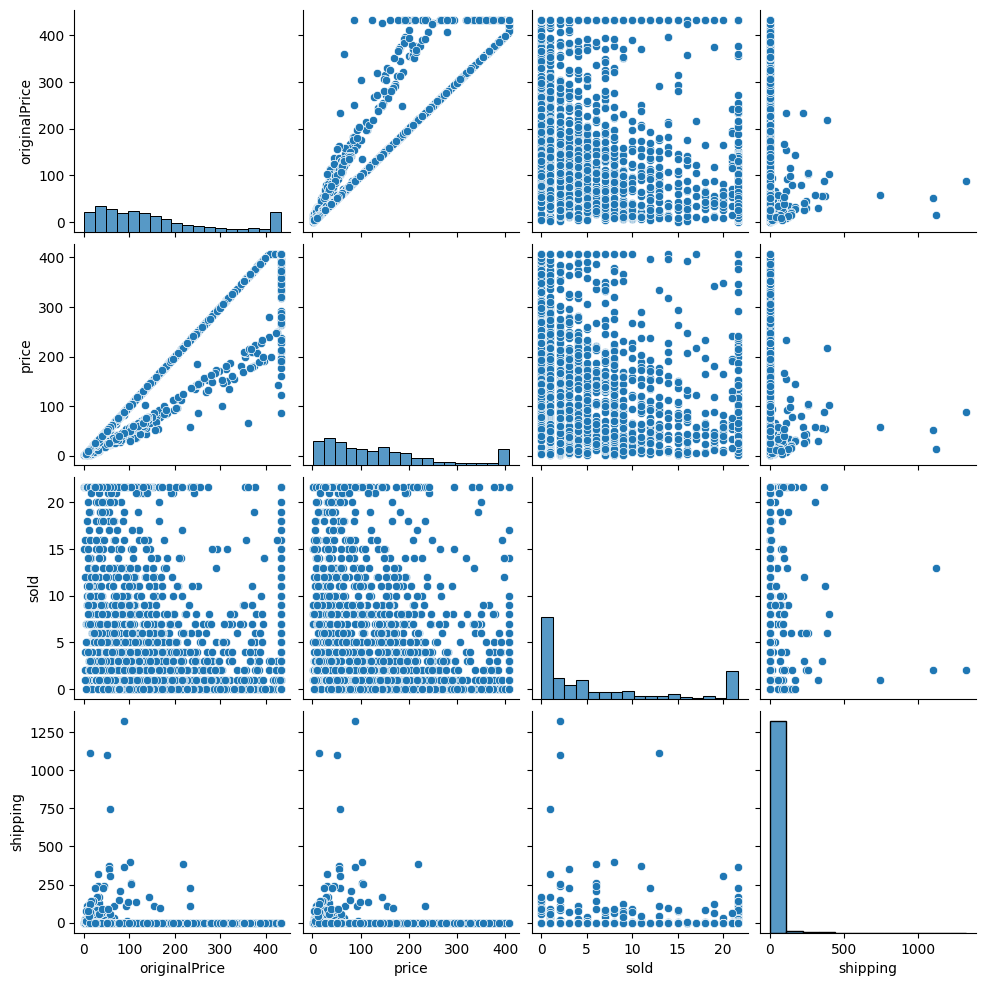

In [ ]:
sns.pairplot(df);

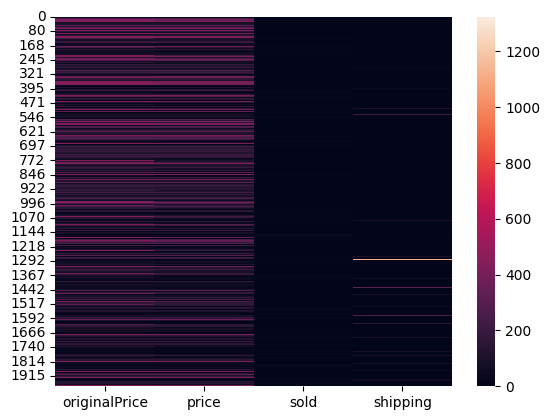

In [ ]:
sns.heatmap(df[['originalPrice', 'price', 'sold', 'shipping']]);

## 3. Feature Engineering

In [ ]:
# create discount feature
df['discount'] = df['originalPrice'] - df['price']
df['discount_percent'] = np.round((df['originalPrice'] - df['price']) / df['originalPrice'],2)

In [ ]:
# create more simple feature
df['title_length'] = df['productTitle'].apply(lambda x: len(str(x)))
df['title_word_count'] = df['productTitle'].apply(lambda x: len(str(x).split()))

In [ ]:
df.head()

,productTitle,originalPrice,price,sold,shipping,discount,discount_percent,title_length,title_word_count
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,46.79,21.625,0.0,0.00,0.00,127,19
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,169.72,0.000,0.0,0.00,0.00,127,18
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7.000,0.0,38.94,0.50,124,19
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",111.99,111.99,0.000,0.0,0.00,0.00,128,17
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1.000,0.0,27.45,0.56,121,17


In [ ]:
# text vectorization for product title col
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
title_tfidf = vectorizer.fit_transform(df['productTitle']).toarray()

# convert to dataframe
title_df = pd.DataFrame(title_tfidf, columns=vectorizer.get_feature_names_out())
title_df.shape

(1904, 2244)

In [ ]:
# concat
df = pd.concat([df.reset_index(drop=True), title_df], axis=1)
df

,productTitle,originalPrice,price,sold,shipping,discount,discount_percent,title_length,title_word_count,00,...,your,zeke,zero,zipper,استرخاء,كرسي,신발장,의자,조립식옷장,협탁
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79000,46.790,21.625,0.0,0.00000,0.00,127,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72000,169.720,0.000,0.0,0.00000,0.00,127,18,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40000,39.460,7.000,0.0,38.94000,0.50,124,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",111.99000,111.990,0.000,0.0,0.00000,0.00,128,17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Small Unit Simple Computer Desk Household Wood...,48.82000,21.370,1.000,0.0,27.45000,0.56,121,17,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,Oversized Outdoor Swivel Rocker Chairs Set wit...,432.91375,407.735,0.000,0.0,25.17875,0.06,121,18,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1900,6pcs Patio Furniture Set PE Rattan Wicker Sect...,325.83000,325.830,4.000,0.0,0.00000,0.00,116,18,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1901,Garden Furniture 4507 (Dark Grey) Steel Frame ...,105.16000,105.160,2.000,0.0,0.00000,0.00,128,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1902,Furniture Acrylic Coffee Table Transparent Liv...,228.18000,228.180,0.000,0.0,0.00000,0.00,124,18,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# drop product title column
df = df.drop(['productTitle'],axis=1)
df.head()

,originalPrice,price,sold,shipping,discount,discount_percent,title_length,title_word_count,00,06,...,your,zeke,zero,zipper,استرخاء,كرسي,신발장,의자,조립식옷장,협탁
0,46.79,46.79,21.625,0.0,0.00,0.00,127,19,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,169.72,169.72,0.000,0.0,0.00,0.00,127,18,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,78.40,39.46,7.000,0.0,38.94,0.50,124,19,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,111.99,111.99,0.000,0.0,0.00,0.00,128,17,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,48.82,21.37,1.000,0.0,27.45,0.56,121,17,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# # Scree plot
# plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Explained Variance Plot')
# plt.grid(True)
# plt.show()

## 4. Prepare data for modeling

In [ ]:
X = df.drop('sold', axis=1)
y = df['sold']

In [ ]:
X

,originalPrice,price,shipping,discount,discount_percent,title_length,title_word_count,00,06,10,...,your,zeke,zero,zipper,استرخاء,كرسي,신발장,의자,조립식옷장,협탁
0,46.79000,46.790,0.0,0.00000,0.00,127,19,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,169.72000,169.720,0.0,0.00000,0.00,127,18,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,78.40000,39.460,0.0,38.94000,0.50,124,19,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,111.99000,111.990,0.0,0.00000,0.00,128,17,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,48.82000,21.370,0.0,27.45000,0.56,121,17,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,432.91375,407.735,0.0,25.17875,0.06,121,18,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1900,325.83000,325.830,0.0,0.00000,0.00,116,18,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1901,105.16000,105.160,0.0,0.00000,0.00,128,19,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1902,228.18000,228.180,0.0,0.00000,0.00,124,18,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Train and Evaluate Regression models

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Support Vector Regression": SVR(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor()
}

# train and evaluate model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    print(f"{name} Mean squared error {mse}")
    print(f"{name} r2 score {r2}")
    print("------------------------------------------------------------")
    print('')

Linear Regression Mean squared error 3921.586541084706
Linear Regression r2 score -75.88931509039826
------------------------------------------------------------

Ridge Regression Mean squared error 35.96866983641171
Ridge Regression r2 score 0.294773592406965
------------------------------------------------------------

Lasso Regression Mean squared error 41.83227964568394
Lasso Regression r2 score 0.1798076373097256
------------------------------------------------------------

Support Vector Regression Mean squared error 44.35428799387611
Support Vector Regression r2 score 0.1303594120791468
------------------------------------------------------------

Random Forest Regressor Mean squared error 36.72538703186804
Random Forest Regressor r2 score 0.2799368761274179
------------------------------------------------------------

Gradient Boosting Regressor Mean squared error 34.255777242428294
Gradient Boosting Regressor r2 score 0.3283577392809419
----------------------------------------